Simulacion de Procesos Financieros

## Examen Parcial 1

Andre Esteban Vera

Insturcciones Canvas:
1.- Se crea un contrato de compra donde se quiere que la acción sea estable. La persona con la que estás haciendo el contrato accede a comprar el 50% de las acciones de tu empresa si la volatilidad móvil con n=20 (anualizada) no excede el 20%. El archivo ex1_01 contiene dos rutas. ¿En cuál de las dos situaciones se activa el contrato?

ex1_01.xlsx


2.- Utilizando S0=100, r=0.05, sigma=0.20, T=1, n=252, y un GBM, considera los siguientes supuestos:

A partir del día 30 sabes que el banco central aumentará las tasas de interés al 8%
Sabes que a partir del día 50, después de una junta de accionistas, la volatilidad aumentará a 40% por 20 días; luego de eso, regresará a la normalidad.
Históricamente, las veces que se ha hecho un anuncio importante sobre el portafolio de la empresa para nuevos productos de venta, se producen reacciones fuertemente positivas e inmediatas en el precio de la acción durante 1 semana; se regresa a la normalidad después de esa semana. La presentación está calendarizada para el día 120.
Incorpora todo esta información en una simulación Monte Carlo con M=10000. Tip: simula día tras día.

## Ejercicio 1



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
datos = pd.read_excel("ex1_01.xlsx")
datos.head()

,Día,Ruta A,Ruta B
0,0,100.0,100.0
1,1,101.2,101.3
2,2,100.4,99.9
3,3,102.0,101.8
4,4,101.5,100.6


In [3]:
log_ret = np.log(datos / datos.shift(1))
vol = log_ret.rolling(20).std() * np.sqrt(252)

print("Volatilidad movil anualizada")
print(f"{'':10}{'maxima':>10}{'minima':>10}{'dias>20%':>12}")

for i in datos.columns:
    v = vol[i].dropna()
    print(f"{i:10} {v.max():>10.4f} {v.min():>10.4f} {(v>0.20).sum():>12}")

print()
for i in datos.columns:
    activa = vol[i].dropna().max() <= 0.20
    print(f"{i}: contrato{'Se Activa' if activa else 'No Se Activa'}")

Volatilidad movil anualizada
              maxima    minima    dias>20%
Día            2.4864     0.0403           13
Ruta A         0.1828     0.1492            0
Ruta B         0.3415     0.2514           40

Día: contratoNo Se Activa
Ruta A: contratoSe Activa
Ruta B: contratoNo Se Activa


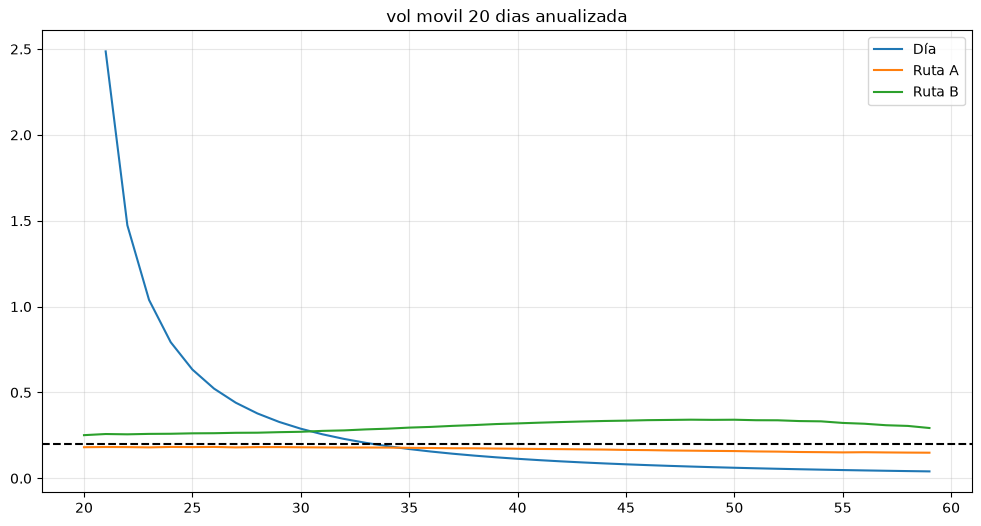

In [4]:
# visualizacion con plot
vol.plot(figsize=(12, 6))
plt.axhline(0.20, color = "k", ls = "--")
plt.title("vol movil 20 dias anualizada")
plt.grid(alpha=0.3); plt.show()

### Interpretacion Ej 1:

El contrato se activa con la ruta A


## Ejercicio 2

In [8]:
S0, T, n , M = 100, 1, 252, 10000
dt = T/n

def r_dia(t): return 0.08 if t >= 30 else 0.05
def sigma_dia(t): return 0.40 if 50 <= t < 70 else 0.20
def mu_dia(t): return 2.0 if 120 <= t < 125 else 0.0

In [12]:
np.random.seed(42)
Z = np.random.normal(0, 1, (M, n))
S = np.zeros((M, n +1)); S[:,0] = S0

for t in range(1, n+1):
    r, s, m = r_dia(t), sigma_dia(t), mu_dia(t)
    S[:,t] = S[:,t-1]*np.exp((r + m - 0.5*s**2)*dt + s*np.sqrt(dt)*Z[:,t-1])

print(S[:,-1].mean(), np.median(S[:,-1]))

112.14440748990769 109.57860596807305


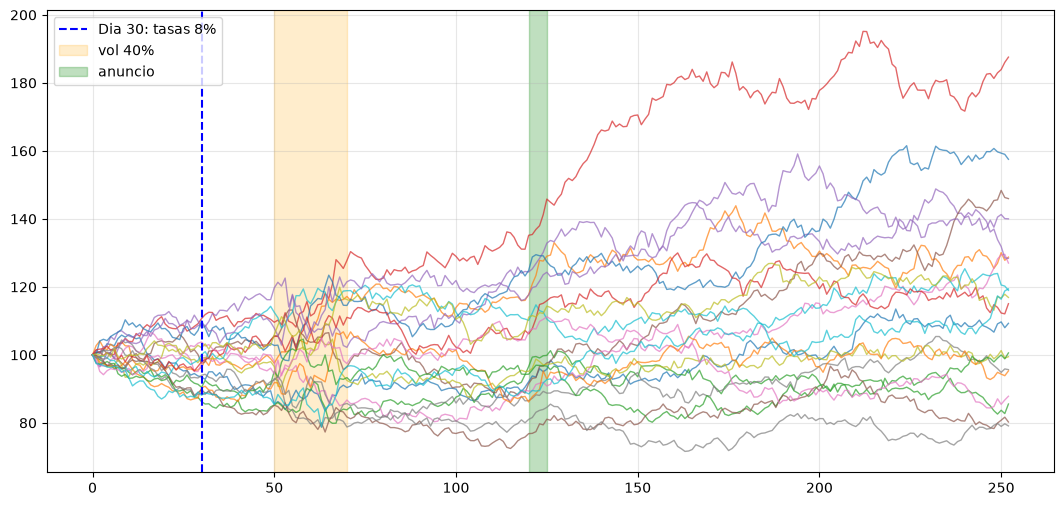

In [14]:
# Visualizacion
plt.figure(figsize=(13,6))
plt.plot(S[:20].T, lw = 1, alpha =.7)
plt.axvline(30, color = "b", ls = "--", label = "Dia 30: tasas 8%")
plt.axvspan(50, 70, color = "orange", alpha = .2, label = "vol 40%")
plt.axvspan(120, 125, color = "green", alpha = .25, label = "anuncio")
plt.legend(); plt.grid(alpha=.3); plt.show()

## Interpretacion Ej2.

La diferencia viene del alza d elas tasas, y cada shock reacciona muy distinto.

el GBM con parametros constantes no puede representar eventos conocidos de antemano